In [2]:
#!pip install -q scikit-learn seaborn matplotlib joblib

In [1]:
import json
import pickle
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import copy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
CLASS_NAMES = ["Human", "AI"]

In [3]:
with open("merged_dataset.jsonl", "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)

In [4]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

df["label"] = df["label"].apply(label_map)

X = df["text"].tolist()
y = df["label"].tolist()


train_texts, val_texts, train_labels, val_labels = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(df["label"].value_counts())

label
0    3060
1    3060
Name: count, dtype: int64


In [5]:
print(df.shape)
print(df.head())

(6120, 7)
                                                text  label AI_used  chunk_no  \
0  engineering (an existing interface is user req...      0    none         1   
1  duction, automated or not. formation, software...      0    none         2   
2  one interactive application to another. In thi...      0    none         3   
3  Of course, a tool may induce some method, but ...      0    none         4   
4  UIs and to introduce based on explicit transfo...      0    none         5   

   source                                         source_url  \
0       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
1       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
2       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
3       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
4       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   

   year_of_publication  
0                 2008  
1                 2008  
2                 2008  
3                 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf = tfidf_vectorizer.transform(val_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
classes = np.unique(y_train)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)

Train TF-IDF shape: (4896, 20000)
Val TF-IDF shape: (1224, 20000)


# **FUNCTIONS**

In [7]:
def plot_dual_curve(x_vals, train_loss, val_loss, train_acc, val_acc, x_label, model_name):
    fig, ax1 = plt.subplots(figsize=(9, 6))

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("Loss")
    line1 = ax1.plot(x_vals, train_loss, color="tab:red", marker="o", label="Train Loss")
    line2 = ax1.plot(x_vals, val_loss, color="tab:orange", marker="o", linestyle="--", label="Val Loss")
    ax1.tick_params(axis="y")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy")
    line3 = ax2.plot(x_vals, train_acc, color="tab:blue", marker="s", label="Train Accuracy")
    line4 = ax2.plot(x_vals, val_acc, color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
    ax2.tick_params(axis="y")

    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="center right")

    plt.title(f"Training/Validation Loss & Accuracy - {model_name}")
    fig.tight_layout()
    plt.show()

In [8]:
def show_examples(y_true, y_pred, texts, model_name, max_per_group=3):
    examples = {
        ("correct", 0): [], ("correct", 1): [],
        ("incorrect", 0): [], ("incorrect", 1): [],
    }
    class_names_map = {0: "Human", 1: "AI"}

    for i in range(len(y_true)):
        true_label = int(y_true[i])
        pred_label = int(y_pred[i])
        is_correct = (true_label == pred_label)
        key = ("correct" if is_correct else "incorrect", true_label)
        if len(examples[key]) < max_per_group:
            examples[key].append(texts[i])

    print(f"\n{'#'*70}\nExample - {model_name}\n{'#'*70}")
    for (status, label), txts in examples.items():
        print(f"\n{'='*60}")
        print(f"{status.upper()} - class: {class_names_map[label]} ({len(txts)} example)")
        print('='*60)
        for j, text in enumerate(txts, 1):
            print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")

In [9]:
def evaluate_and_report(model, model_name, X_val_vec, y_val, val_texts, is_keras=False, threshold=0.5):
    if is_keras:
        y_proba = model.predict(X_val_vec).flatten()
        y_pred = (y_proba > threshold).astype(int)
    else:
        y_pred = model.predict(X_val_vec)

    print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4))

    conf_mat = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_mat, annot=True, fmt="d", cmap="BuGn",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    show_examples(y_val, y_pred, val_texts, model_name)
    return y_pred

In [10]:
def export_classic_model(model, filename):
    joblib.dump(model, filename)
    print(f"Model saved: {filename}")

def train_with_early_stopping(model, X_train_vec, y_train, X_val_vec, y_val, classes,
                               indices, loss_fn, max_epochs=100, patience=5, model_name=""):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_loss = np.inf
    best_model = None
    epochs_without_improvement = 0
    epoch = 0

    while epoch < max_epochs:
        rng.shuffle(indices)
        model.partial_fit(X_train_vec[indices], y_train[indices], classes=classes)
        epoch += 1

        train_loss = loss_fn(model, X_train_vec, y_train)
        val_loss = loss_fn(model, X_val_vec, y_val)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(accuracy_score(y_train, model.predict(X_train_vec)))
        val_accs.append(accuracy_score(y_val, model.predict(X_val_vec)))

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch} "
                  f"(val loss has not improved for {patience} epochs)")
            break

    if best_model is None:
        best_model = model

    return best_model, train_losses, val_losses, train_accs, val_accs


results_summary = {}

def record_results(model_name, y_val, y_pred):
    report = classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
    results_summary[model_name] = {
        "accuracy": report["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
    }

# **Logistic Regression**

[Logistic Regression] Early stopping at epoch 6 (val loss has not improved for 5 epochs)


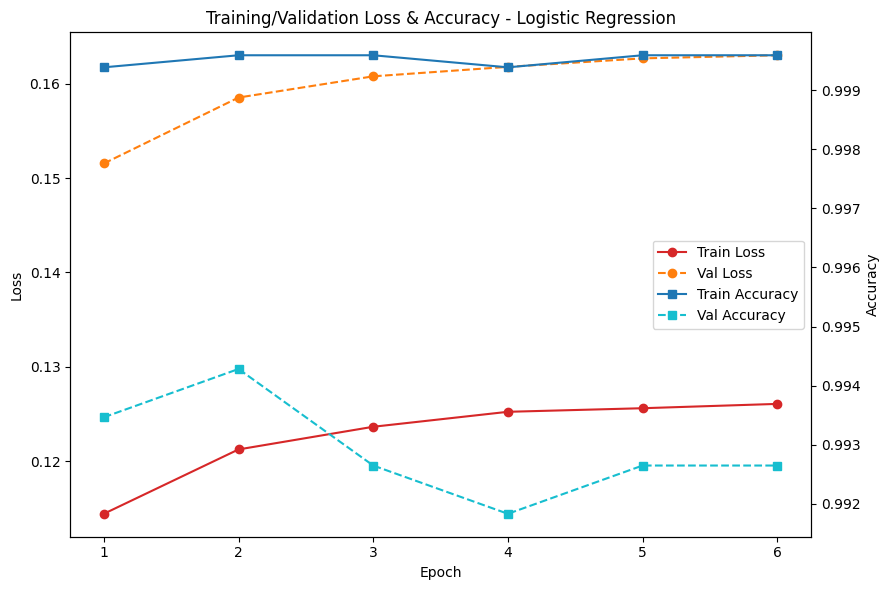

In [ ]:
indices = np.arange(X_train_tfidf.shape[0])

def logreg_log_loss(model, X, y):
    return log_loss(y, model.predict_proba(X), labels=[0, 1])

logreg_model, lr_train_losses, lr_val_losses, lr_train_accs, lr_val_accs = train_with_early_stopping(
    SGDClassifier(loss="log_loss", random_state=RANDOM_STATE, warm_start=True),
    X_train_tfidf, y_train, X_val_tfidf, y_val, classes, indices,
    loss_fn=logreg_log_loss, max_epochs=100, patience=5, model_name="Logistic Regression"
)

plot_dual_curve(range(1, len(lr_train_losses) + 1), lr_train_losses, lr_val_losses,
                lr_train_accs, lr_val_accs, x_label="Epoch", model_name="Logistic Regression")

              precision    recall  f1-score   support

       Human     0.9903    0.9967    0.9935       612
          AI     0.9967    0.9902    0.9934       612

    accuracy                         0.9935      1224
   macro avg     0.9935    0.9935    0.9935      1224
weighted avg     0.9935    0.9935    0.9935      1224



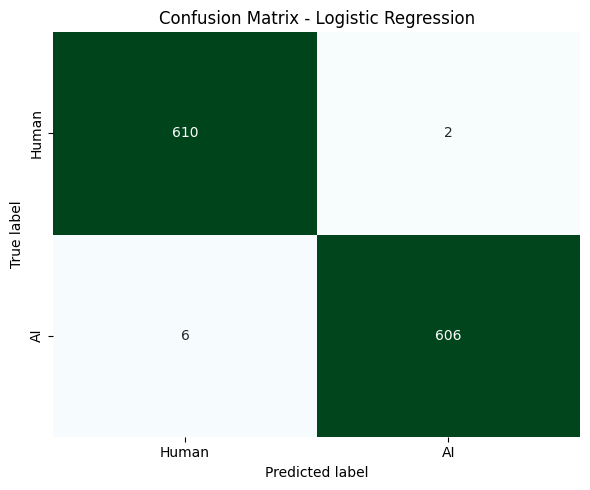


######################################################################
Example - Logistic Regression
######################################################################

CORRECT - class: Human (3 example)

[1] Presupunând că invarianța formei modelului este stabilită, următorul nivel de testare este invarianța metrică. Scopul testării invarianței metrice este de a se asigura că grupurile diferite răspund la itemi în același mod astfel încât se pot face comparări între grupuri. Prin invarianța metrică se t...

[2] Fenomenul are loc pe fondul colaborării cu departamentele interne și cu organizațiile din componența ariei de activitate, produsele oferite clienților trebuind să fie executate la standarde deosebite de calitate. Fiecare angajat ar trebui să se pună în locul clientului pentru a putea crea o ofertă d...

[3] Literatura de specialitate abordează modelele arhitecturale comune, în principal după elementul cheie specific acestora (Tabel 1), cu avantajele și dezavantajele pe car

In [ ]:
y_pred_lr = evaluate_and_report(logreg_model, "Logistic Regression", X_val_tfidf, y_val, val_texts)
record_results("Logistic Regression", y_val, y_pred_lr)
export_classic_model(logreg_model, "logistic_regression_model.joblib")

joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.joblib")
print("Vectorizator TF-IDF saved: tfidf_vectorizer.joblib")

# **Decision Tree**

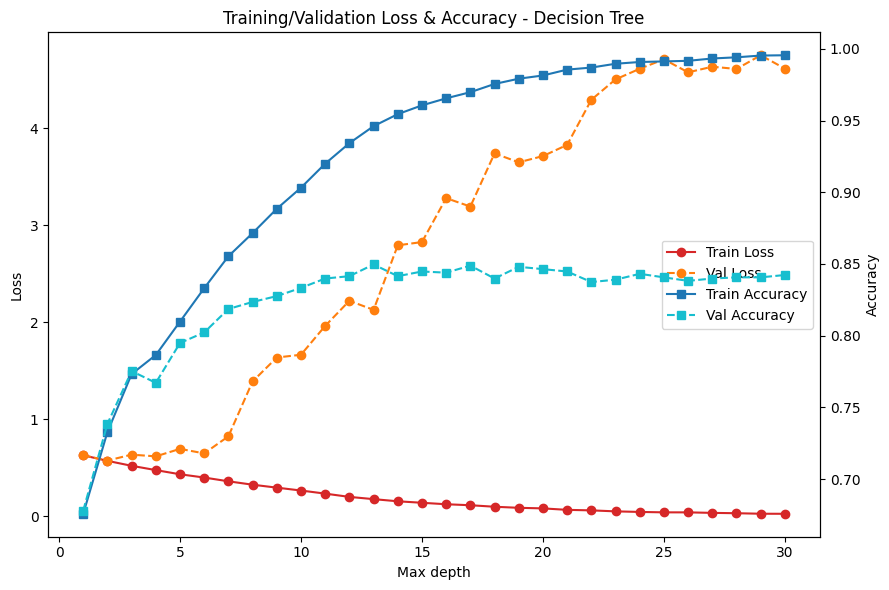

Best depth based on accuracy: 13


DecisionTreeClassifier(max_depth=13, random_state=42)

In [ ]:
depths = list(range(1, 31))
dt_train_losses, dt_val_losses, dt_train_accs, dt_val_accs = [], [], [], []

for d in depths:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt_tmp.fit(X_train_tfidf, y_train)

    train_proba = dt_tmp.predict_proba(X_train_tfidf)
    val_proba = dt_tmp.predict_proba(X_val_tfidf)

    dt_train_losses.append(log_loss(y_train, train_proba, labels=[0, 1]))
    dt_val_losses.append(log_loss(y_val, val_proba, labels=[0, 1]))
    dt_train_accs.append(accuracy_score(y_train, dt_tmp.predict(X_train_tfidf)))
    dt_val_accs.append(accuracy_score(y_val, dt_tmp.predict(X_val_tfidf)))

plot_dual_curve(depths, dt_train_losses, dt_val_losses, dt_train_accs, dt_val_accs,
                x_label="Max depth", model_name="Decision Tree")

best_depth = depths[int(np.argmax(dt_val_accs))]
print("Best depth based on accuracy:", best_depth)

dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_model.fit(X_train_tfidf, y_train)

              precision    recall  f1-score   support

       Human     0.8567    0.8399    0.8482       612
          AI     0.8429    0.8595    0.8511       612

    accuracy                         0.8497      1224
   macro avg     0.8498    0.8497    0.8497      1224
weighted avg     0.8498    0.8497    0.8497      1224



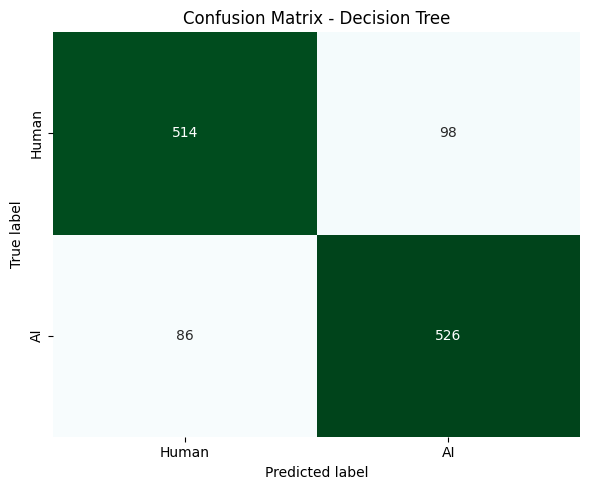


######################################################################
Example - Decision Tree
######################################################################

CORRECT - class: Human (3 example)

[1] Presupunând că invarianța formei modelului este stabilită, următorul nivel de testare este invarianța metrică. Scopul testării invarianței metrice este de a se asigura că grupurile diferite răspund la itemi în același mod astfel încât se pot face comparări între grupuri. Prin invarianța metrică se t...

[2] Fenomenul are loc pe fondul colaborării cu departamentele interne și cu organizațiile din componența ariei de activitate, produsele oferite clienților trebuind să fie executate la standarde deosebite de calitate. Fiecare angajat ar trebui să se pună în locul clientului pentru a putea crea o ofertă d...

[3] Literatura de specialitate abordează modelele arhitecturale comune, în principal după elementul cheie specific acestora (Tabel 1), cu avantajele și dezavantajele pe care le o

In [ ]:
y_pred_dt = evaluate_and_report(dt_model, "Decision Tree", X_val_tfidf, y_val, val_texts)
record_results("Decision Tree", y_val, y_pred_dt)
export_classic_model(dt_model, "decision_tree_model.joblib")

# **Random Forest**

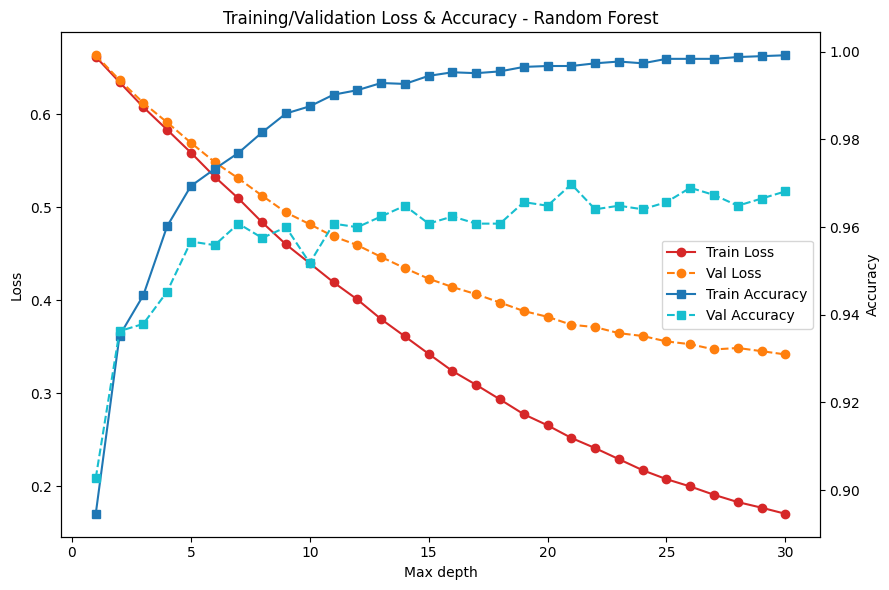

Best depth based on accuracy: 21


RandomForestClassifier(max_depth=21, n_jobs=-1, random_state=42)

In [13]:
depths = list(range(1, 31))
rf_depth_train_losses, rf_depth_val_losses, rf_depth_train_accs, rf_depth_val_accs = [], [], [], []

for d in depths:
    rf_tmp = RandomForestClassifier(max_depth=d, random_state=RANDOM_STATE, n_jobs=-1)
    rf_tmp.fit(X_train_tfidf, y_train)

    train_proba = rf_tmp.predict_proba(X_train_tfidf)
    val_proba = rf_tmp.predict_proba(X_val_tfidf)

    rf_depth_train_losses.append(log_loss(y_train, train_proba, labels=[0, 1]))
    rf_depth_val_losses.append(log_loss(y_val, val_proba, labels=[0, 1]))
    rf_depth_train_accs.append(accuracy_score(y_train, rf_tmp.predict(X_train_tfidf)))
    rf_depth_val_accs.append(accuracy_score(y_val, rf_tmp.predict(X_val_tfidf)))

plot_dual_curve(depths, rf_depth_train_losses, rf_depth_val_losses, rf_depth_train_accs, rf_depth_val_accs,
                x_label="Max depth", model_name="Random Forest")

best_depth_rf = depths[int(np.argmax(rf_depth_val_accs))]
print("Best depth based on accuracy:", best_depth_rf)

rf_model = RandomForestClassifier(max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

              precision    recall  f1-score   support

       Human     0.9736    0.9657    0.9696       612
          AI     0.9660    0.9739    0.9699       612

    accuracy                         0.9698      1224
   macro avg     0.9698    0.9698    0.9698      1224
weighted avg     0.9698    0.9698    0.9698      1224



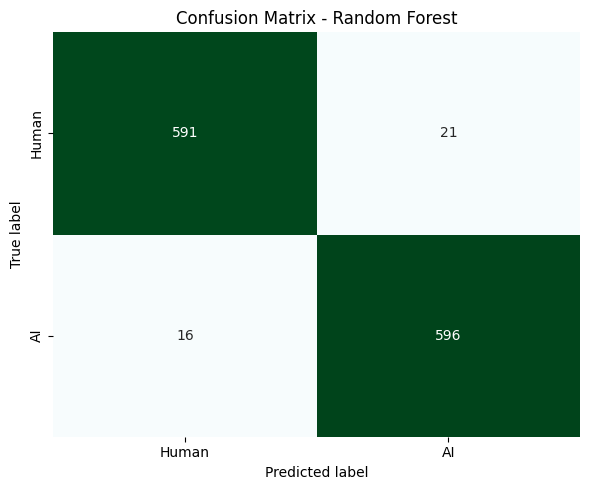


######################################################################
Example - Random Forest
######################################################################

CORRECT - class: Human (3 example)

[1] Presupunând că invarianța formei modelului este stabilită, următorul nivel de testare este invarianța metrică. Scopul testării invarianței metrice este de a se asigura că grupurile diferite răspund la itemi în același mod astfel încât se pot face comparări între grupuri. Prin invarianța metrică se t...

[2] Fenomenul are loc pe fondul colaborării cu departamentele interne și cu organizațiile din componența ariei de activitate, produsele oferite clienților trebuind să fie executate la standarde deosebite de calitate. Fiecare angajat ar trebui să se pună în locul clientului pentru a putea crea o ofertă d...

[3] Literatura de specialitate abordează modelele arhitecturale comune, în principal după elementul cheie specific acestora (Tabel 1), cu avantajele și dezavantajele pe care le o

In [14]:
y_pred_rf = evaluate_and_report(rf_model, "Random Forest", X_val_tfidf, y_val, val_texts)
record_results("Random Forest", y_val, y_pred_rf)
export_classic_model(rf_model, "random_forest_model.joblib")

# **Support Vector Machines**

[SVM] Early stopping at epoch 6 (val loss has not improved for 5 epochs)


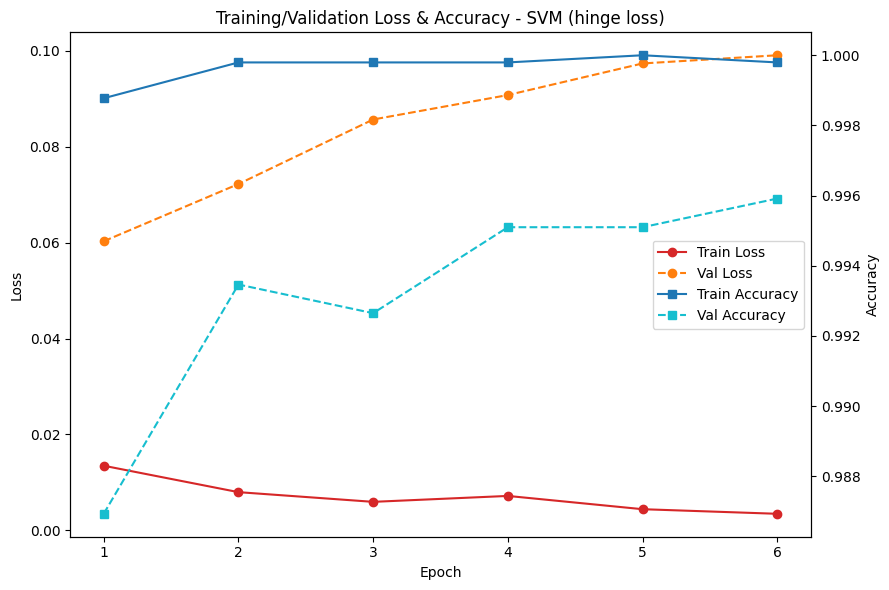

In [ ]:
def hinge_loss_manual(y_true, decision_values):
    y_signed = np.where(y_true == 1, 1, -1)
    losses = np.maximum(0, 1 - y_signed * decision_values)
    return float(np.mean(losses))

def svm_hinge_loss(model, X, y):
    return hinge_loss_manual(y, model.decision_function(X))

svm_model, svm_train_losses, svm_val_losses, svm_train_accs, svm_val_accs = train_with_early_stopping(
    SGDClassifier(loss="hinge", random_state=RANDOM_STATE, warm_start=True),
    X_train_tfidf, y_train, X_val_tfidf, y_val, classes, indices,
    loss_fn=svm_hinge_loss, max_epochs=100, patience=5, model_name="SVM"
)

plot_dual_curve(range(1, len(svm_train_losses) + 1), svm_train_losses, svm_val_losses,
                svm_train_accs, svm_val_accs, x_label="Epoch", model_name="SVM (hinge loss)")

              precision    recall  f1-score   support

       Human     0.9838    0.9902    0.9870       612
          AI     0.9901    0.9837    0.9869       612

    accuracy                         0.9869      1224
   macro avg     0.9869    0.9869    0.9869      1224
weighted avg     0.9869    0.9869    0.9869      1224



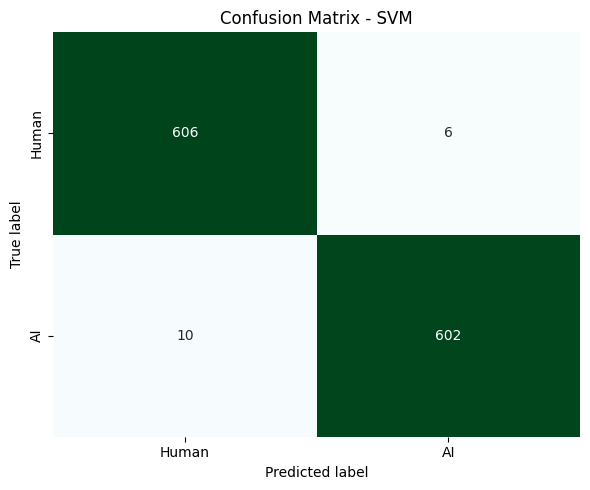


######################################################################
Example - SVM
######################################################################

CORRECT - class: Human (3 example)

[1] Presupunând că invarianța formei modelului este stabilită, următorul nivel de testare este invarianța metrică. Scopul testării invarianței metrice este de a se asigura că grupurile diferite răspund la itemi în același mod astfel încât se pot face comparări între grupuri. Prin invarianța metrică se t...

[2] Fenomenul are loc pe fondul colaborării cu departamentele interne și cu organizațiile din componența ariei de activitate, produsele oferite clienților trebuind să fie executate la standarde deosebite de calitate. Fiecare angajat ar trebui să se pună în locul clientului pentru a putea crea o ofertă d...

[3] Literatura de specialitate abordează modelele arhitecturale comune, în principal după elementul cheie specific acestora (Tabel 1), cu avantajele și dezavantajele pe care le oferă utili

In [ ]:
y_pred_svm = evaluate_and_report(svm_model, "SVM", X_val_tfidf, y_val, val_texts)
record_results("SVM", y_val, y_pred_svm)
export_classic_model(svm_model, "svm_model.joblib")

# **Naive Bayes**

[Naive Bayes] Early stopping at epoch 79 (val loss has not improved for 5 epochs)


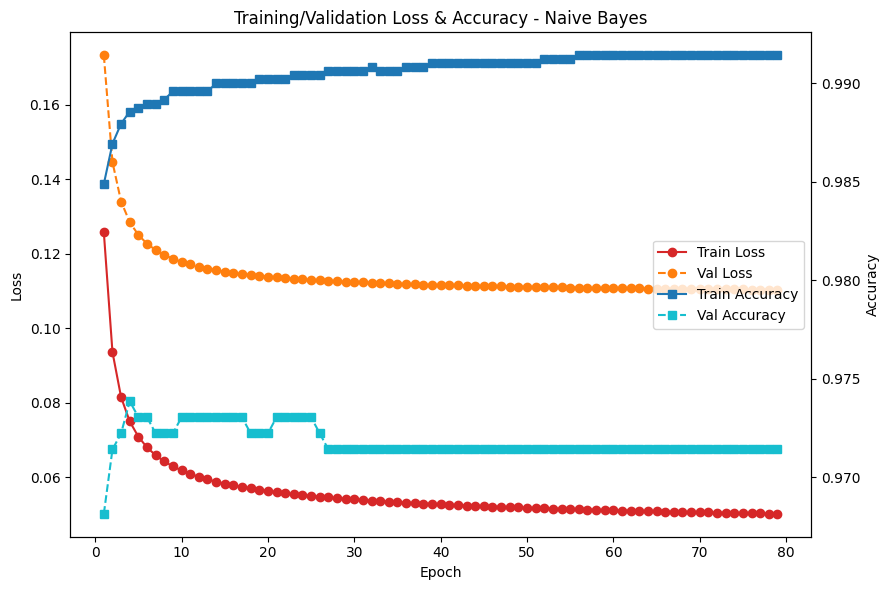

In [ ]:
def nb_log_loss(model, X, y):
    return log_loss(y, model.predict_proba(X), labels=[0, 1])

nb_model, nb_train_losses, nb_val_losses, nb_train_accs, nb_val_accs = train_with_early_stopping(
    MultinomialNB(), X_train_tfidf, y_train, X_val_tfidf, y_val, classes, indices,
    loss_fn=nb_log_loss, max_epochs=100, patience=5, model_name="Naive Bayes"
)

plot_dual_curve(range(1, len(nb_train_losses) + 1), nb_train_losses, nb_val_losses,
                nb_train_accs, nb_val_accs, x_label="Epoch", model_name="Naive Bayes")

              precision    recall  f1-score   support

       Human     0.9784    0.9641    0.9712       612
          AI     0.9646    0.9788    0.9716       612

    accuracy                         0.9714      1224
   macro avg     0.9715    0.9714    0.9714      1224
weighted avg     0.9715    0.9714    0.9714      1224



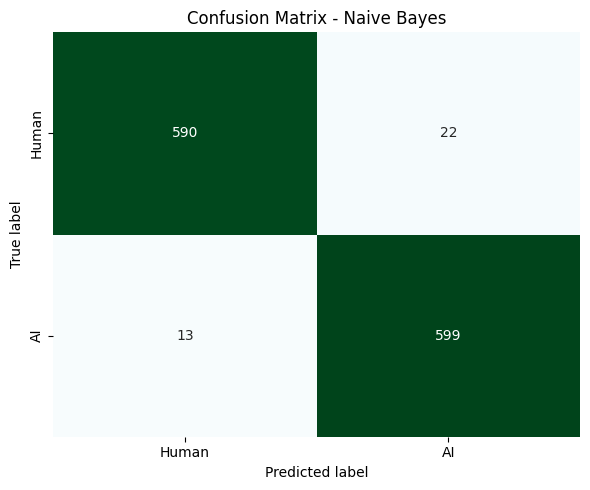


######################################################################
Example - Naive Bayes
######################################################################

CORRECT - class: Human (3 example)

[1] Presupunând că invarianța formei modelului este stabilită, următorul nivel de testare este invarianța metrică. Scopul testării invarianței metrice este de a se asigura că grupurile diferite răspund la itemi în același mod astfel încât se pot face comparări între grupuri. Prin invarianța metrică se t...

[2] Fenomenul are loc pe fondul colaborării cu departamentele interne și cu organizațiile din componența ariei de activitate, produsele oferite clienților trebuind să fie executate la standarde deosebite de calitate. Fiecare angajat ar trebui să se pună în locul clientului pentru a putea crea o ofertă d...

[3] Literatura de specialitate abordează modelele arhitecturale comune, în principal după elementul cheie specific acestora (Tabel 1), cu avantajele și dezavantajele pe care le ofe

In [ ]:
y_pred_nb = evaluate_and_report(nb_model, "Naive Bayes", X_val_tfidf, y_val, val_texts)
record_results("Naive Bayes", y_val, y_pred_nb)
export_classic_model(nb_model, "naive_bayes_model.joblib")

# **Bi-LSTM**

In [ ]:
VOCAB_SIZE = 20000
MAX_LEN = 512
EMBEDDING_DIM = 128

lstm_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
lstm_tokenizer.fit_on_texts(train_texts)

train_sequences = lstm_tokenizer.texts_to_sequences(train_texts)
val_sequences = lstm_tokenizer.texts_to_sequences(val_texts)

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
val_padded = pad_sequences(val_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train padded shape:", train_padded.shape)
print("Val padded shape:", val_padded.shape)

Train padded shape: (4896, 512)
Val padded shape: (1224, 512)


In [ ]:
bilstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = bilstm_model.fit(
    train_padded, y_train,
    validation_data=(val_padded, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.8319 - loss: 0.3575 - val_accuracy: 0.9714 - val_loss: 0.1180
Epoch 2/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9824 - loss: 0.0588 - val_accuracy: 0.9657 - val_loss: 0.1057
Epoch 3/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9920 - loss: 0.0285 - val_accuracy: 0.9559 - val_loss: 0.1338
Epoch 4/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9937 - loss: 0.0221 - val_accuracy: 0.9616 - val_loss: 0.1684
Epoch 5/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9978 - loss: 0.0083 - val_accuracy: 0.9559 - val_loss: 0.1872


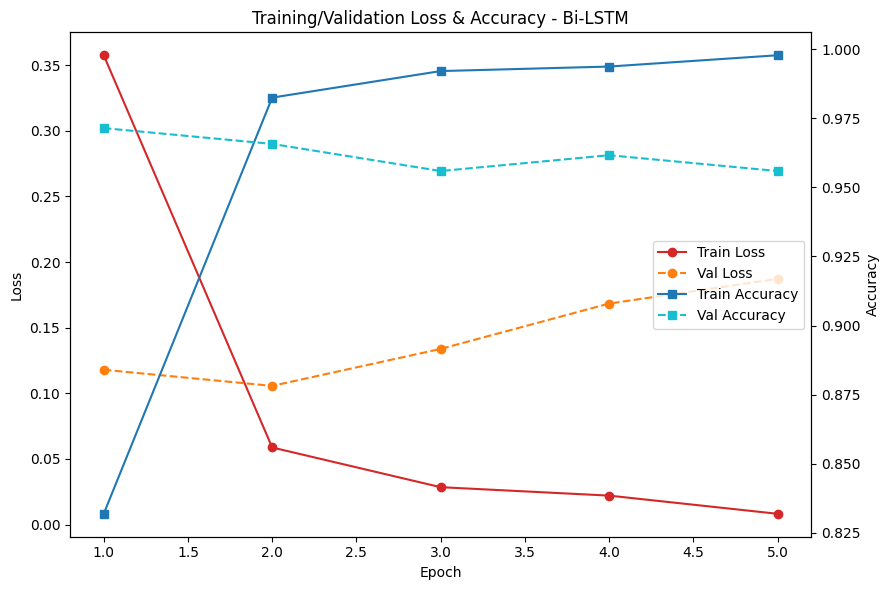

In [ ]:
hist = history_lstm.history
epochs_range = range(1, len(hist["loss"]) + 1)

plot_dual_curve(
    list(epochs_range), hist["loss"], hist["val_loss"], hist["accuracy"], hist["val_accuracy"],
    x_label="Epoch", model_name="Bi-LSTM"
)

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
              precision    recall  f1-score   support

       Human     0.9672    0.9641    0.9656       612
          AI     0.9642    0.9673    0.9657       612

    accuracy                         0.9657      1224
   macro avg     0.9657    0.9657    0.9657      1224
weighted avg     0.9657    0.9657    0.9657      1224



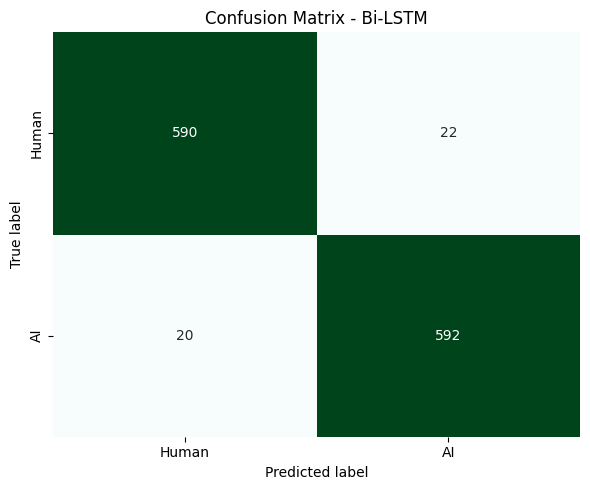


######################################################################
Example - Bi-LSTM
######################################################################

CORRECT - class: Human (3 example)

[1] Presupunând că invarianța formei modelului este stabilită, următorul nivel de testare este invarianța metrică. Scopul testării invarianței metrice este de a se asigura că grupurile diferite răspund la itemi în același mod astfel încât se pot face comparări între grupuri. Prin invarianța metrică se t...

[2] Fenomenul are loc pe fondul colaborării cu departamentele interne și cu organizațiile din componența ariei de activitate, produsele oferite clienților trebuind să fie executate la standarde deosebite de calitate. Fiecare angajat ar trebui să se pună în locul clientului pentru a putea crea o ofertă d...

[3] Literatura de specialitate abordează modelele arhitecturale comune, în principal după elementul cheie specific acestora (Tabel 1), cu avantajele și dezavantajele pe care le oferă u

In [ ]:
y_pred_lstm = evaluate_and_report(bilstm_model, "Bi-LSTM", val_padded, y_val, val_texts, is_keras=True)
record_results("Bi-LSTM", y_val, y_pred_lstm)

In [ ]:
bilstm_model.save("bilstm_model.keras")

with open("lstm_tokenizer.pickle", "wb") as f:
    pickle.dump(lstm_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Model saved: bilstm_model.keras")
print("Tokenizer saved: lstm_tokenizer.pickle")

Model saved: bilstm_model.keras
Tokenizer saved: lstm_tokenizer.pickle


# **Model download**

In [ ]:
import os

export_dir = "./exported_models"
os.makedirs(export_dir, exist_ok=True)

files_to_move = [
    "tfidf_vectorizer.joblib",
    "decision_tree_model.joblib",
    "naive_bayes_model.joblib",
    "random_forest_model.joblib",
    "svm_model.joblib",
    "logistic_regression_model.joblib",
    "lstm_tokenizer.pickle",
]

for fname in files_to_move:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(export_dir, fname))

# bilstm_model.keras e un folder/fisier - il copiem separat
if os.path.exists("bilstm_model.keras"):
    shutil.copy("bilstm_model.keras", os.path.join(export_dir, "bilstm_model.keras"))

shutil.make_archive("all_models", "zip", export_dir)

from google.colab import files
files.download("all_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import os

export_dir = "./exported_models"
os.makedirs(export_dir, exist_ok=True)

files_to_move = [
    "random_forest_model.joblib",
]

for fname in files_to_move:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(export_dir, fname))

shutil.make_archive("all_models_2", "zip", export_dir)

from google.colab import files
files.download("all_models_2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>